<a href="https://colab.research.google.com/github/tallapragadaananya-a11y/ML-2-1-Skill1/blob/main/Week%204/Spotify_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
['Class_Code_Explained (1).ipynb', 'Maths_for_AI_Session2_Matrices_NN (1).ipynb', 'Week1_Cosine_Similarity_Case_Studies_Solutions.ipynb', 'Gradient_Descent_Session.ipynb', 'SVD-Rank-k-Approximation.ipynb', 'case study 2.ipynb', 'case study 1.ipynb', 'placement_predict_50k.csv', 'EXP-1.ipynb', 'Most Streamed Artists on Spotify.csv', 'placement_predict_50k Dataset.csv', 'placement_dataset.csv', 'Untitled1.ipynb', 'age_insurance.csv', 'placement_predict_50k_adjusted.csv', 'Exp-2.ipynb', 'Spotify-1.ipynb']
Dataset shape: (500, 14)

Columns:
['Artist Name', 'Sex', 'Country of Origin', 'Primary Language', 'Primary Genre', ' Artist Type', 'Debut Year', 'Total Streams (in millions)', 'Lead Streams (in millions)', 'Feature Streams (in millions)', 'Solo Streams (in millions)', '% of Solo Streams', 'Collaborative Streams (in millions)', '% of Collaborative Streams']

First 5 rows:
     Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0          Dra

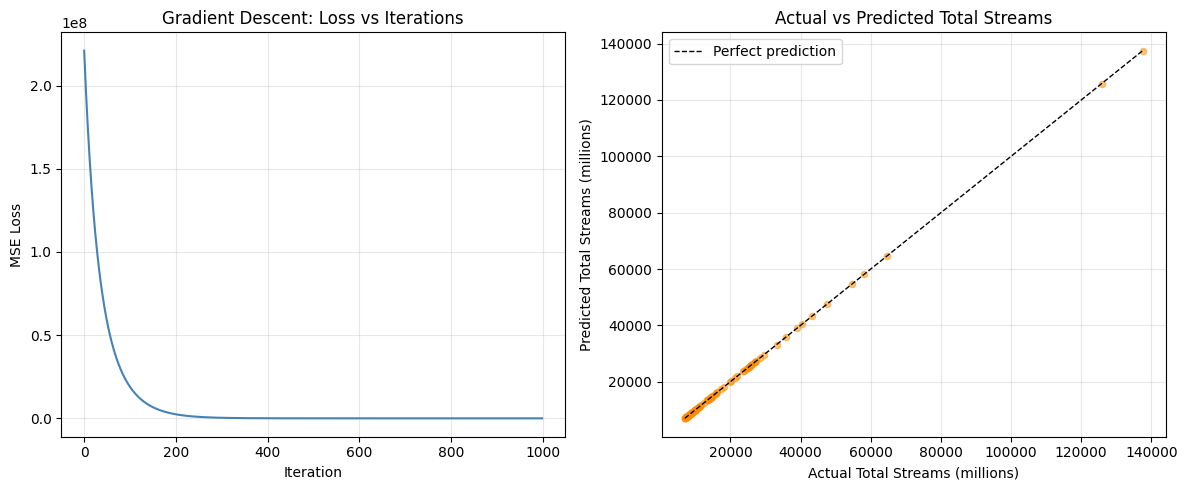

In [3]:
from google.colab import drive

drive.mount('/content/drive')

import os

print(os.listdir('/content/drive/MyDrive/Colab'))


# =========================================================
# 2. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# =========================================================
# 3. LOAD SPOTIFY DATASET
# =========================================================

df = pd.read_csv(
    "/content/drive/MyDrive/Colab/Most Streamed Artists on Spotify.csv"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# =========================================================
# 4. SELECT TARGET AND FEATURES
# =========================================================

# We want to predict Total Streams
target_col = "Total Streams (in millions)"

# Numerical features available in the Spotify dataset
feature_cols = [
    "Debut Year",
    "Lead Streams (in millions)",
    "Feature Streams (in millions)",
    "Solo Streams (in millions)",
    "% of Solo Streams",
    "Collaborative Streams (in millions)",
    "% of Collaborative Streams"
]

# Keep only required columns
feature_df = df[feature_cols].copy()


# =========================================================
# 5. HANDLE MISSING VALUES
# =========================================================

# Replace missing numerical values with median
feature_df = feature_df.fillna(feature_df.median())

# Remove rows where target is missing
valid_rows = df[target_col].notna()

X = feature_df.loc[valid_rows].values
y = df.loc[valid_rows, target_col].values.reshape(-1, 1)


print("\nNumber of samples:", len(y))
print("Number of features:", X.shape[1])


# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# =========================================================
# 7. FEATURE SCALING
# =========================================================

# Scaling helps Gradient Descent converge properly

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Add bias/intercept column
X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]


# =========================================================
# 8. GRADIENT DESCENT
# =========================================================

def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape

    # Initialize weights
    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta

        # Error
        error = y_pred - y

        # Mean Squared Error loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        # Gradient
        gradient = (1 / m) * (X.T @ error)

        # Update weights
        theta -= lr * gradient

        if i % 100 == 0:
            print(
                f"Iteration {i:4d} | Loss: {loss:.4f}"
            )

    return theta, losses


# Run Gradient Descent
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)


# =========================================================
# 9. PREDICTION
# =========================================================

y_pred = X_test_b @ theta


# =========================================================
# 10. EVALUATION
# =========================================================

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n======================================")
print("MODEL RESULTS")
print("======================================")

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R²  : {r2:.4f}")


# =========================================================
# 11. COMPARE WITH SKLEARN LINEAR REGRESSION
# =========================================================

from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train
)

sk_pred = sk_model.predict(X_test)

sk_r2 = r2_score(
    y_test,
    sk_pred
)

sk_mse = mean_squared_error(
    y_test,
    sk_pred
)

print("\n======================================")
print("SKLEARN LINEAR REGRESSION")
print("======================================")

print(f"sklearn MSE : {sk_mse:.4f}")
print(f"sklearn R²  : {sk_r2:.4f}")


# =========================================================
# 12. PLOTS
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ---------------------------------------------------------
# A. Gradient Descent Loss Curve
# ---------------------------------------------------------

axes[0].plot(
    range(len(losses)),
    losses,
    color="steelblue"
)

axes[0].set_title(
    "Gradient Descent: Loss vs Iterations"
)

axes[0].set_xlabel(
    "Iteration"
)

axes[0].set_ylabel(
    "MSE Loss"
)

axes[0].grid(
    alpha=0.3
)


# ---------------------------------------------------------
# B. Actual vs Predicted Total Streams
# ---------------------------------------------------------

axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    s=20,
    color="darkorange"
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title(
    "Actual vs Predicted Total Streams"
)

axes[1].set_xlabel(
    "Actual Total Streams (millions)"
)

axes[1].set_ylabel(
    "Predicted Total Streams (millions)"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "spotify_gradient_descent_plots.png",
    dpi=150
)

print(
    "\nSaved plots to spotify_gradient_descent_plots.png"
)

plt.show()